### Analyzing S&P 500 Index Performance with ARIMA Time Series Analysis
By Stephanie Nguyen

#### Project Topic

This project explores the application of ARIMA time-series modeling to analyze and interpret patterns in the performance of the S&P 500 index.

### A. RESEARCH QUESTION 

To what extent can variable <i>Close</i> be predicted using ARIMA time series modeling?

#### Hypothesis:
<b>Null Hypothesis:</b> Variable <i>Close</i> cannot be predicted at 90% accuracy. <br>
<b>Alternate Hypothesis:</b> Variable <i>Close</i> can be predicted at 90% accuracy.<br>

#### Context

The stock market is volatile, so understanding patterns and performance trends in the S&P 500 index is crucial for making better financial decisions. Analyzing these trends helps traders and investors identify opportunities, avoid losses, and refine their strategies. By applying the ARIMA time-series model to 10 years of historical data, patterns can be examined to gain insights into market movements. ARIMA is particularly effective for identifying trends, seasonality, and relationships in the data, making it a valuable tool for understanding market changes and improving decision-making.

#### Summary of Assumptions

The ARIMA model assumes that the time series is stationary, with a constant mean and variance over time. ARIMA also relies on autocorrelation, using past values in the data to help predict future values. 

### B. DATA COLLECTION

#### Description of Data
The dataset includes the daily open, high, low, and close prices for the S&P index, covering all trading days from December 1, 2014, to December 1, 2024, spanning a total of 10 years. The data is sourced from FactSet Research Systems and published by the Wall Street Journal.

The data on the S&P index is owned by S&P Dow Jones Indices, which sources financial information from market exchanges. FactSet Research Systems compiles and distributes this data under a licensing agreement with S&P Dow Jones Indices, and the Wall Street Journal publishes the data under its own distribution agreement with FactSet. I am permitted to use this data for my capstone project under non-commercial, educational fair use. This data is intended exclusively for informational and analytical purposes and is not to be used for trading or commercial activities.

#### Data Gathering
The data was gathered by downloading a CSV file, named <i>HistoricalPrices</i>, directly from the Wall Street Journal (WSJ) website. The WSJ publishes historical price data for the S&P index, which is sourced from FactSet Research Systems, a licensed distributor of financial market information.

#### Data Analytics Tools and Techniques
The data analysis technique for this project is time-series analysis using the ARIMA (Auto-Regressive Integrated Moving Average) model. 

#### Justification of Tools and Techniques
ARIMA is ideal for analyzing the performance of the S&P 500 index because it effectively identifies patterns, trends, and seasonality in historical data, providing valuable insights into market behavior. 

#### PACKAGES AND LIBRARIES LIST

In [ ]:
# !pip install pandas_market_calendars

In [ ]:
# !pip install pmdarima

In [ ]:
# Importing all libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_market_calendars as pmc

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Augmented Dickey-fuller (ADF) test for stationarity
from statsmodels.tsa.stattools import adfuller

# decomposition 
from statsmodels.tsa.seasonal import seasonal_decompose

# train/test split
from sklearn.model_selection import train_test_split

# ACF, PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Power Spectral Density (PSD)
import matplotlib.pyplot as plt
from scipy import signal

# auto_arima tells us if there is seasonality and gives Python's recommendation for p, d, q values 
from pmdarima import auto_arima

# ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# RSME error metric
from sklearn.metrics import mean_squared_error as mse
from math import sqrt


In [ ]:
# Load/import HistoricalPrices.csv data set
df = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\14. ARIMA Time Series Modeling for S&P 500 (SPX)\Data\HistoricalPrices.csv")

#### Preview the data set

In [ ]:
# Get the number of rows and columns in the dataframe
df.shape

(2517, 5)

In [ ]:
df.columns

Index(['Date', ' Open', ' High', ' Low', ' Close'], dtype='object')

The original time series data set has 2517 observations and 5 columns: <i>Date, Open, High, Low,</i> and <i>Close </i>.

In [ ]:
# Preview the data
pd.set_option('display.max_columns',None)
df.head()

,Date,Open,High,Low,Close
0,11/29/24,6003.98,6044.17,6003.98,6032.38
1,11/27/24,6014.11,6020.16,5984.87,5998.74
2,11/26/24,6000.03,6025.42,5992.27,6021.63
3,11/25/24,5992.28,6020.75,5963.91,5987.37
4,11/22/24,5944.36,5972.90,5944.36,5969.34


In [ ]:
# Get overview of columns and data types in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2517 non-null   object 
 1    Open   2517 non-null   float64
 2    High   2517 non-null   float64
 3    Low    2517 non-null   float64
 4    Close  2517 non-null   float64
dtypes: float64(4), object(1)
memory usage: 98.4+ KB


### C. DATA EXTRACTION AND PREPARATION

#### Data Cleaning
The data set is checked for null and duplicated values during the data cleaning phase.

In [ ]:
# Detect null values
df.isnull().sum()

Date      0
 Open     0
 High     0
 Low      0
 Close    0
dtype: int64

No missing values were detected from the time series data.

In [ ]:
print(df.columns)

Index(['Date', ' Open', ' High', ' Low', ' Close'], dtype='object')


In [ ]:
# Remove any leading or trailing whitespaces in column names
df.rename(columns=lambda x: x.strip(), inplace=True)

In [ ]:
# Preview the change
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')


In [ ]:
# Check for duplicates across all columns
df.duplicated().value_counts()

False    2517
Name: count, dtype: int64

No duplicated values were detected from the time series data.

In [ ]:
# Convert the Date column to datetime format
df['Date'] = pd.to_datetime(df['Date']).dt.date

# Sort your dataframe by the date column
df.sort_values(by='Date', inplace=True)

In [ ]:
# Load the New York Stock Exchange (NYSE) calendar
nyse = pmc.get_calendar('NYSE')

# Define the date range (10 years starting on December 1, 2014 to December 1, 2024)
start_date = '2014-12-01'
end_date = '2024-12-01'

# Get the valid trading days for the given range
schedule = nyse.schedule(start_date=start_date, end_date=end_date)
trading_days = pmc.date_range(schedule, frequency='1D')

print(trading_days)

DatetimeIndex(['2014-12-01 21:00:00+00:00', '2014-12-02 21:00:00+00:00',
               '2014-12-03 21:00:00+00:00', '2014-12-04 21:00:00+00:00',
               '2014-12-05 21:00:00+00:00', '2014-12-08 21:00:00+00:00',
               '2014-12-09 21:00:00+00:00', '2014-12-10 21:00:00+00:00',
               '2014-12-11 21:00:00+00:00', '2014-12-12 21:00:00+00:00',
               ...
               '2024-11-15 21:00:00+00:00', '2024-11-18 21:00:00+00:00',
               '2024-11-19 21:00:00+00:00', '2024-11-20 21:00:00+00:00',
               '2024-11-21 21:00:00+00:00', '2024-11-22 21:00:00+00:00',
               '2024-11-25 21:00:00+00:00', '2024-11-26 21:00:00+00:00',
               '2024-11-27 21:00:00+00:00', '2024-11-29 18:00:00+00:00'],
              dtype='datetime64[ns, UTC]', length=2517, freq=None)


In [ ]:
# Identify missing trading days
missing_days = len(trading_days) - len(df['Date'])

# Print number of missing trading days
print("Missing Trading Days:", missing_days)

Missing Trading Days: 0


#### Time Step Formatting

In [ ]:
# Length of the sequence
seq_len = len(df)

print(f"Time step format: days")
print(f"Length of the sequence: {seq_len} days")

Time step format: days
Length of the sequence: 2517 days


The realization is formatted in daily time steps, showing no observable gaps in the measurements. The data set consists of 2517 trading days, representing a 10-year period.

In [ ]:
# Set the index to align with the existing data
df = df.set_index(trading_days[:len(df)])

# Drop the original Date column
df.drop(columns='Date', inplace=True)

print(df)

                              Open     High      Low    Close
2014-12-01 21:00:00+00:00  2065.78  2065.78  2049.57  2053.44
2014-12-02 21:00:00+00:00  2053.77  2068.77  2053.77  2066.55
2014-12-03 21:00:00+00:00  2067.45  2076.28  2066.65  2074.33
2014-12-04 21:00:00+00:00  2073.64  2077.34  2062.34  2071.92
2014-12-05 21:00:00+00:00  2072.78  2079.47  2070.81  2075.37
...                            ...      ...      ...      ...
2024-11-22 21:00:00+00:00  5944.36  5972.90  5944.36  5969.34
2024-11-25 21:00:00+00:00  5992.28  6020.75  5963.91  5987.37
2024-11-26 21:00:00+00:00  6000.03  6025.42  5992.27  6021.63
2024-11-27 21:00:00+00:00  6014.11  6020.16  5984.87  5998.74
2024-11-29 18:00:00+00:00  6003.98  6044.17  6003.98  6032.38

[2517 rows x 4 columns]


#### Line Graph Visualizations
A line graph was plotted to visualize the trend in the time series S&P 500 Index data.

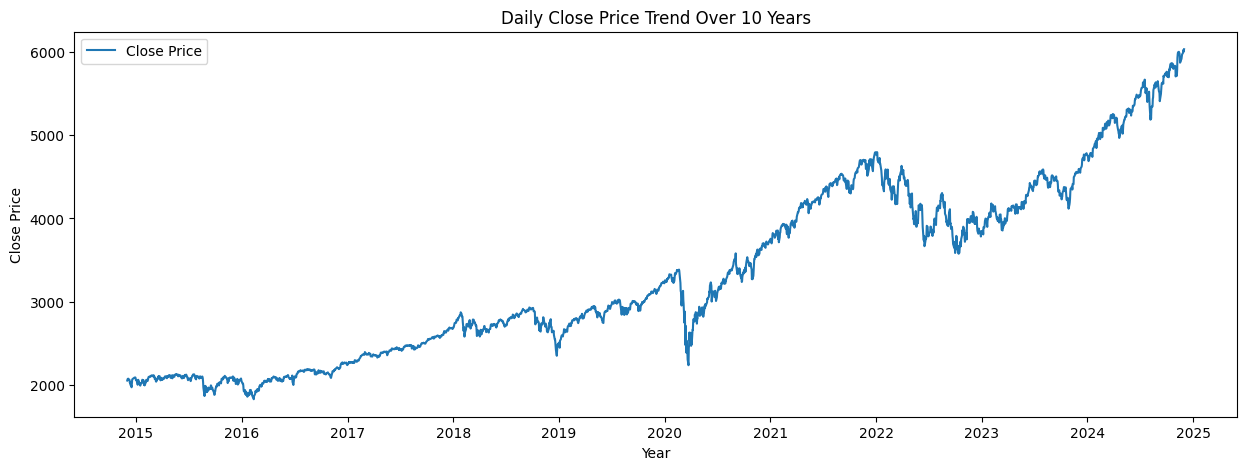

In [ ]:
# Plot daily close price trend over 10 years
plt.figure(figsize=(15,5))
plt.plot(df['Close'], label='Close Price')
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.title('Daily Close Price Trend Over 10 Years')
plt.legend(loc="upper left")
plt.savefig('S&P 500 Index Close Price by Day Over 10 Years.png',bbox_inches='tight')
plt.show()

In [ ]:
# Find the drop between year 2018 and 2019
start_date = '2018-01-01'
end_date = '2019-01-31'
min_value = df.loc[start_date:end_date, 'Close'].min()
date_min_value = df[df['Close'] == min_value].index[0]

print("Lowest Close Price between 2018 and 2019: ", round(min_value,0))
print("Date: ", date_min_value)

Lowest Close Price between 2018 and 2019:  2351.0
Date:  2018-12-24 18:00:00+00:00


In [ ]:
# Find the drop between year 2020 and 2021
start_date = '2020-01-01'
end_date = '2021-01-31'
min_value = df.loc[start_date:end_date, 'Close'].min()
date_min_value = df[df['Close'] == min_value].index[0]

print("Lowest Close Price between 2020 and 2021: ", round(min_value,0))
print("Date: ", date_min_value)

Lowest Close Price between 2020 and 2021:  2237.0
Date:  2020-03-23 20:00:00+00:00


In [ ]:
ts = pd.Series(df['Close'].values, index = df.index)
ts.head()

2014-12-01 21:00:00+00:00    2053.44
2014-12-02 21:00:00+00:00    2066.55
2014-12-03 21:00:00+00:00    2074.33
2014-12-04 21:00:00+00:00    2071.92
2014-12-05 21:00:00+00:00    2075.37
dtype: float64

In [ ]:
len(ts)

2517

#### Stationarity
The augmented Dickey-Fuller test was used to check for stationarity and the p-value is obtained from ADF test results.

In [ ]:
# Augmented Dickey-Fuller test for stationarity mathematically
dickey_fuller_test = adfuller(ts, autolag = 'AIC')
print("Augmented Dickey-Fuller Test Results: ")
print("ADF: ", dickey_fuller_test[0])
print("P-value: ", dickey_fuller_test[1])
print("Number of lags: ", dickey_fuller_test[2])
print("Number of observations used for ADF regression and critical values calc: ", dickey_fuller_test[3])
print("Critical values: ")
for key, val in dickey_fuller_test[4].items():
    print("\t", key,": ",val)

Augmented Dickey-Fuller Test Results: 
ADF:  0.7431774866586343
P-value:  0.9906613106672583
Number of lags:  10
Number of observations used for ADF regression and critical values calc:  2506
Critical values: 
	 1% :  -3.432962135264372
	 5% :  -2.862694028699462
	 10% :  -2.567384333962417


With 2517 original data points, the ADF test uses only 2506 because it defaults to a maximum of 10 lags in this case. The inclusion of 10 lags means the first 10 observations are excluded to compute the lagged values. Additionally, one observation is lost during differencing, as the test compares each point to the previous one to evaluate stationarity, and the first observation cannot be used because it lacks a predecessor for comparison.

The ADF test result shows a p-value of 0.99, which is greater than 0.05, indicating that the data is likely not stationary. <br>
The data must be stationary in order to make the mean and variance constant.

p < 0.05 means that the data is stationary<br>
p > 0.05 means that the data is not stationary<br>

The time series data was differenced and stored as a Pandas series, indexed by day. Stationarity was then assessed using the ADF test. 

In [ ]:
# Use differencing to make the data stationary before applying the time series model
# Perform first-order differencing
diff_ts = pd.Series(ts.diff(), index = ts.index[1:])
diff_ts.head()

2014-12-02 21:00:00+00:00    13.11
2014-12-03 21:00:00+00:00     7.78
2014-12-04 21:00:00+00:00    -2.41
2014-12-05 21:00:00+00:00     3.45
2014-12-08 21:00:00+00:00   -15.06
dtype: float64

In [ ]:
len(diff_ts)

2516

When you difference a time series, the first data point is lost because the process involves subtracting each previous value from the current one. This shifts the entire dataset forward by one time step, causing the differenced series to start on 2014-12-02. As a result, the total number of observations decreases from 2517 to 2516.

#### Augmented Dickey-Fuller (ADF) Test

In [ ]:
# Augmented Dickey-Fuller test for stationarity mathematically
dickey_fuller_test = adfuller(diff_ts, autolag = 'AIC')
print("Augmented Dickey-Fuller Test Results: ")
print("ADF: ", dickey_fuller_test[0])
print("P-value: ", dickey_fuller_test[1])
print("Number of lags: ", dickey_fuller_test[2])
print("Number of observations used for ADF regression and critical values calc: ", dickey_fuller_test[3])
print("Critical values: ")
for key, val in dickey_fuller_test[4].items():
    print("\t", key,": ",val)

Augmented Dickey-Fuller Test Results: 
ADF:  -15.995296252928329
P-value:  6.602185687788397e-29
Number of lags:  9
Number of observations used for ADF regression and critical values calc:  2506
Critical values: 
	 1% :  -3.432962135264372
	 5% :  -2.862694028699462
	 10% :  -2.567384333962417


Re-running the ADF test on the lagged data produces a p-value below 0.05. A very small p-value (such as 6.60218568778802e-29) in the ADF test strongly suggests stationarity. The "d" parameter represents the number of differencing steps needed to make the time series stationary; in this case, d=1.

Next, the data was split into 80/20 training and test sets for ARIMA modeling, with the first 2013 days used for training and the last 504 days reserved for testing.

#### Splitting the Data

In [ ]:
# Split the data 80/20
train_size = int(len(df) * 0.8)
train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print('Train:', train.shape)
print('Test:', test.shape)

Train: (2013,)
Test: (504,)


In [ ]:
print('Train:')
print(train)
print('Test:')
print(test)

Train:
2014-12-01 21:00:00+00:00    2053.44
2014-12-02 21:00:00+00:00    2066.55
2014-12-03 21:00:00+00:00    2074.33
2014-12-04 21:00:00+00:00    2071.92
2014-12-05 21:00:00+00:00    2075.37
                              ...   
2022-11-21 21:00:00+00:00    3949.94
2022-11-22 21:00:00+00:00    4003.58
2022-11-23 21:00:00+00:00    4027.26
2022-11-25 18:00:00+00:00    4026.12
2022-11-28 21:00:00+00:00    3963.94
Length: 2013, dtype: float64
Test:
2022-11-29 21:00:00+00:00    3957.63
2022-11-30 21:00:00+00:00    4080.11
2022-12-01 21:00:00+00:00    4076.57
2022-12-02 21:00:00+00:00    4071.70
2022-12-05 21:00:00+00:00    3998.84
                              ...   
2024-11-22 21:00:00+00:00    5969.34
2024-11-25 21:00:00+00:00    5987.37
2024-11-26 21:00:00+00:00    6021.63
2024-11-27 21:00:00+00:00    5998.74
2024-11-29 18:00:00+00:00    6032.38
Length: 504, dtype: float64


#### Prepared Data Set

In [ ]:
# Export prepared data set
diff_ts.to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\14. ARIMA Time Series Modeling for S&P 500 (SPX)\Outputs\diff_ts.csv",index=False)

In [ ]:
# Export the training and test data set to csv files
pd.Series(train).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\14. ARIMA Time Series Modeling for S&P 500 (SPX)\Outputs\train.csv",index=False)
pd.Series(test).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\14. ARIMA Time Series Modeling for S&P 500 (SPX)\Outputs\test.csv",index=False)

#### Report Findings and Visualizations

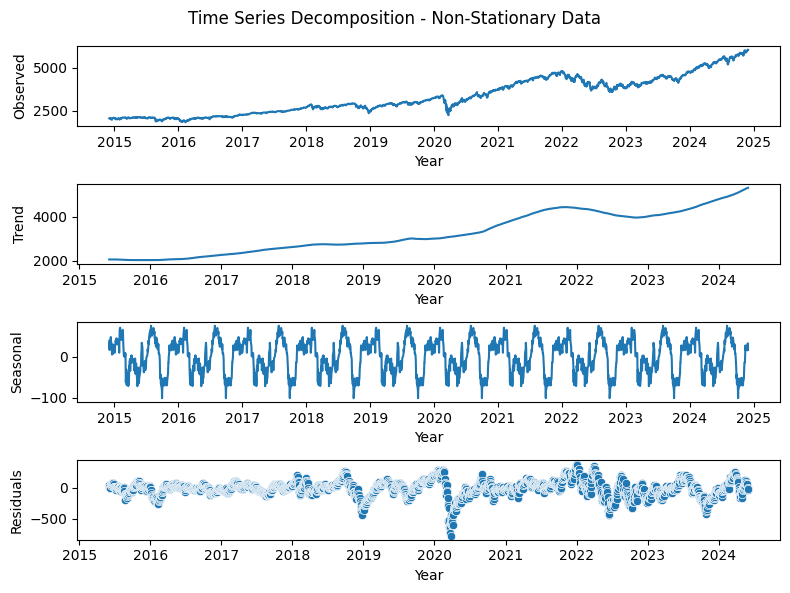

In [ ]:
# Decomposition - before differencing
# Typically 252 trading days in a year
decomp = seasonal_decompose(ts, model='additive', period = 252)

fig, ax = plt.subplots(4, figsize = (8,6))
plt.suptitle('Time Series Decomposition - Non-Stationary Data')
sns.lineplot(data=decomp.observed, ax=ax[0])
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Observed')
sns.lineplot(data=decomp.trend, ax=ax[1])
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Trend')
sns.lineplot(data=decomp.seasonal, ax=ax[2])
ax[2].set_xlabel('Year')
ax[2].set_ylabel('Seasonal')
sns.scatterplot(data=decomp.resid, ax=ax[3])
ax[3].set_xlabel('Year')
ax[3].set_ylabel('Residuals')

# Adjust layout
plt.tight_layout()
plt.savefig('Time Series Decomposition - Non-Stationary Data.png')

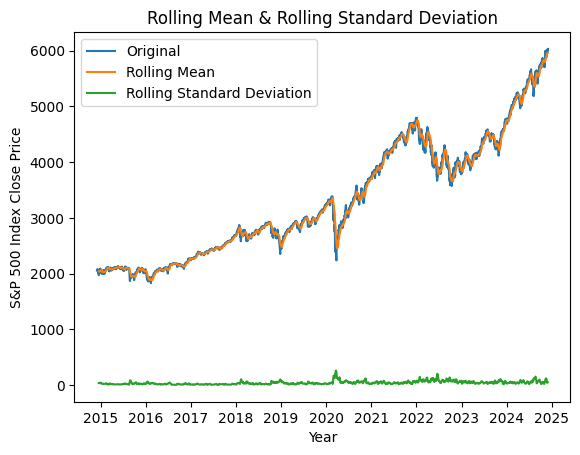

In [ ]:
# Rolling mean - check for seasonality
rolling_mean = ts.rolling(window=12).mean()
rolling_std = ts.rolling(window=12).std()

original = plt.plot(ts, label = 'Original')
mean = plt.plot(rolling_mean, label = 'Rolling Mean')
std = plt.plot(rolling_std, label = 'Rolling Standard Deviation')
plt.legend(loc='best')
plt.title('Rolling Mean & Rolling Standard Deviation')
plt.xlabel('Year')
plt.ylabel('S&P 500 Index Close Price')
plt.savefig('Rolling Mean & Rolling Standard Deviation.png')
plt.show()

The graph shows an upward trend in the rolling mean and a stable rolling standard deviation, indicating a trend rather than seasonality. The lack of cyclical patterns suggests the data likely does not have seasonality, as seasonal data would show regular peaks and troughs in both metrics.

#### Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)
The ACF is used to determine the moving average (MA) term, represented by "q," while the PACF helps identify the autoregressive (AR) term, represented by "p." Together, they provide the values needed to capture important patterns in the ARIMA model.

#### ACF and PACF of Non-Stationary Data

<Figure size 800x600 with 0 Axes>

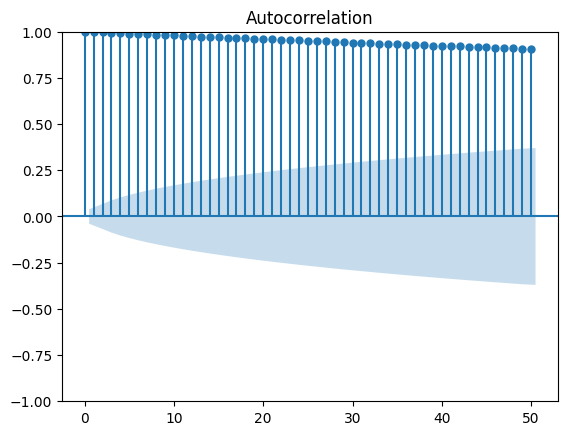

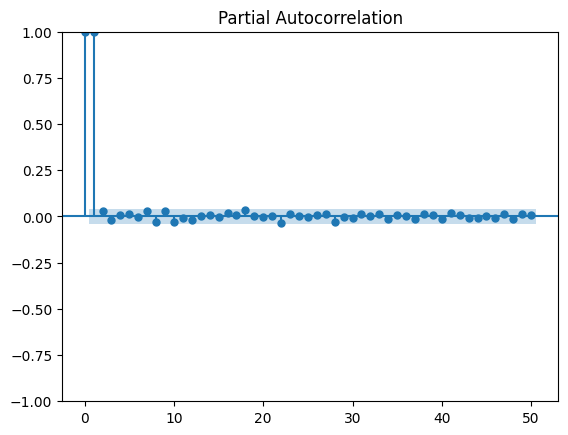

In [ ]:
plt.figure(figsize=(8,6))

# Autocorrelation Function (ACF) - before differencing
plot_acf(ts, lags = 50)
plt.savefig('ACF of Non-Stationary Data.png')
# Partial Autocorrelation Function (PACF) - before differencing
plot_pacf(ts, lags = 50)
plt.savefig('PACF of Non-Stationary Data.png')
plt.show()

#### ACF and PACF of Stationary Data

<Figure size 800x600 with 0 Axes>

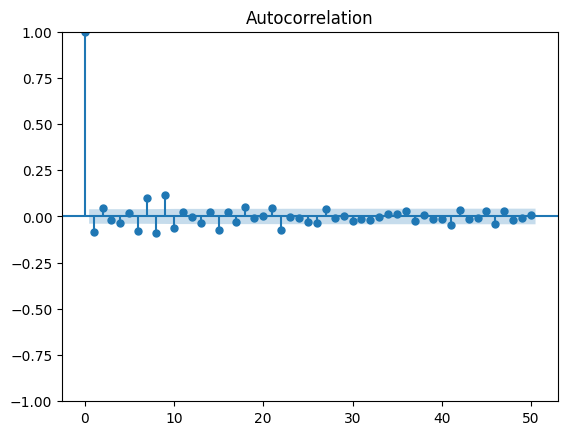

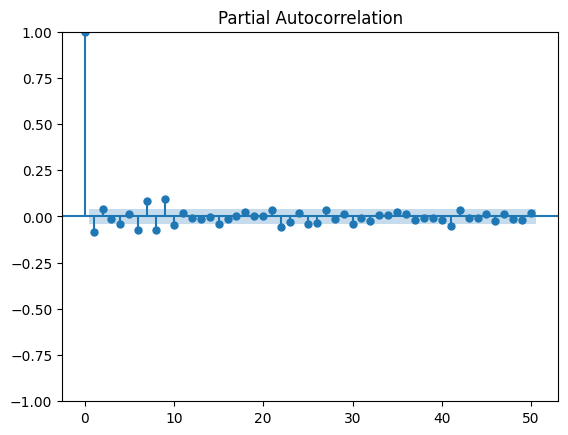

In [ ]:
# Autocorrelation Function (ACF) - after differencing
plt.figure(figsize=(8,6))

plot_acf(diff_ts, lags = 50)
plt.savefig('ACF of Stationary Data.png')
# Partial Autocorrelation Function (PACF) - after differencing
plot_pacf(diff_ts, lags = 50)
plt.savefig('PACF of Stationary Data.png')

plt.show()

#### Spectral Density
Spectral density reveals the underlying signal in a time series and helps identify seasonality by highlighting observable patterns and recurring cycles.

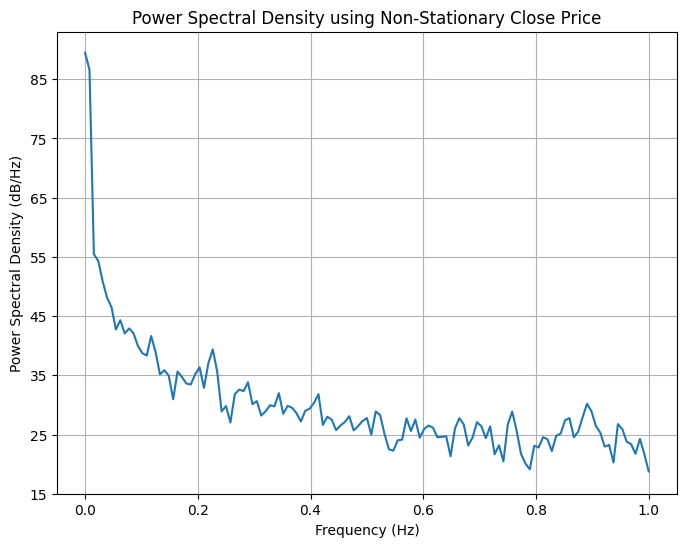

In [ ]:
# Power Spectral Density using the Non-Stationary Revenue Data
plt.figure(figsize=(8,6))
plt.psd(ts)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (dB/Hz)')
plt.title('Power Spectral Density using Non-Stationary Close Price')
plt.savefig('Power Spectral Density using Non-Stationary Close Price.png')
plt.show()

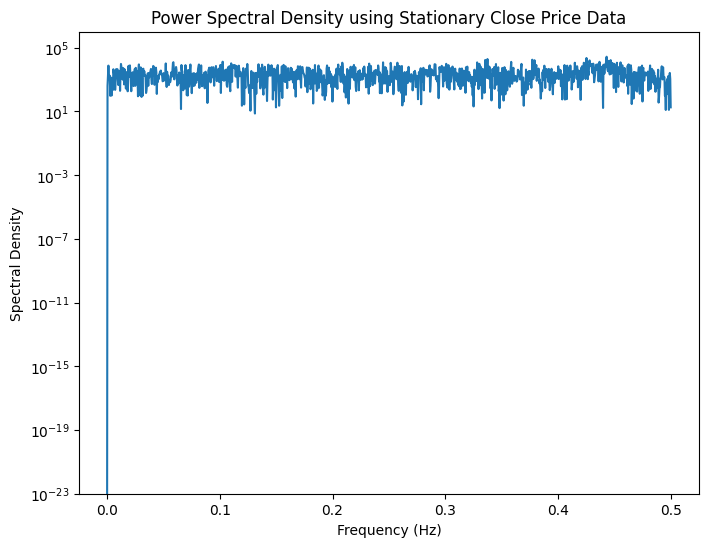

In [ ]:
# Power Spectral Density using the Stationary Data
f, Pxx_den = signal.periodogram(diff_ts)

plt.figure(figsize=(8,6))
plt.semilogy(f, Pxx_den)
plt.ylim([10e-24,10e5])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Spectral Density')
plt.title('Power Spectral Density using Stationary Close Price Data')
plt.savefig('Power Spectral Density using Stationary Close Price Data.png')
plt.show()

The Power Spectral Density (PSD) graph of the stationary Close price data indicates that all frequencies contribute to the signal, with varying magnitudes.

#### Decomposed Time Series
Decomposition provides a deeper understanding of the time series data by isolating the trend, seasonality, and residuals. 

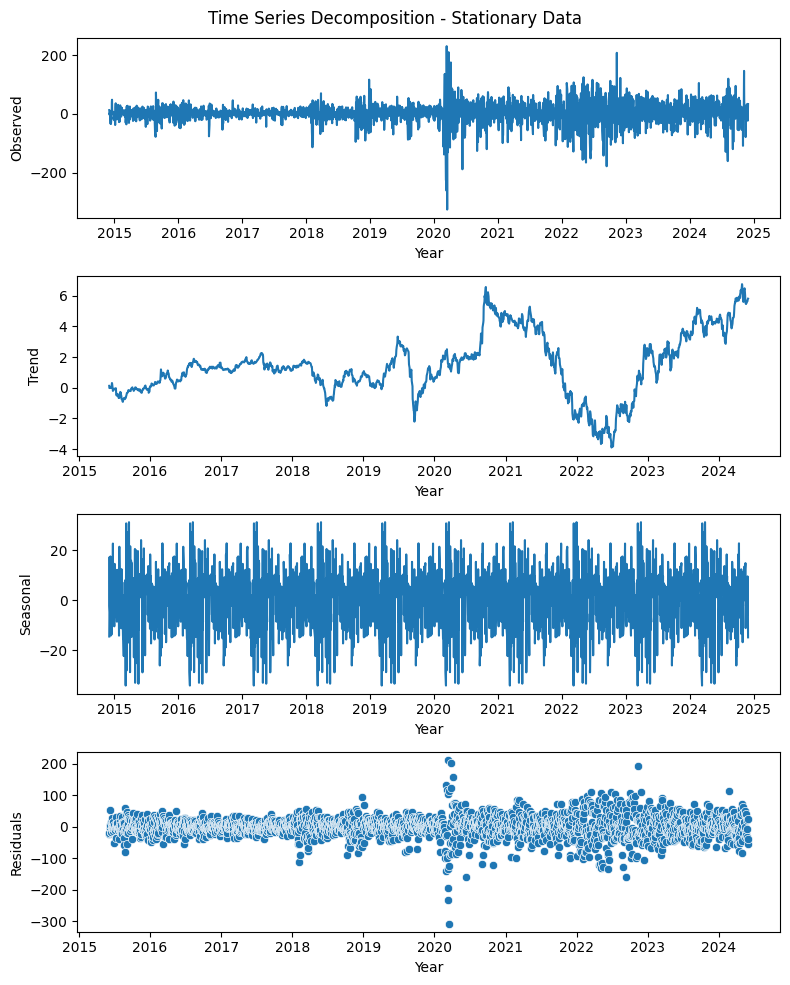

In [ ]:
# Decomposed time series - Stationary Data
# Plots trend with noise, trend without noise, seasonality, residuals
decomp_diff = seasonal_decompose(diff_ts, model='additive', period = 252)

fig, ax = plt.subplots(4, figsize = (8,10))
plt.suptitle('Time Series Decomposition - Stationary Data')
sns.lineplot(data=decomp_diff.observed, ax=ax[0])
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Observed')
sns.lineplot(data=decomp_diff.trend, ax=ax[1])
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Trend')
sns.lineplot(data=decomp_diff.seasonal, ax=ax[2])
ax[2].set_xlabel('Year')
ax[2].set_ylabel('Seasonal')
sns.scatterplot(data=decomp_diff.resid, ax=ax[3])
ax[3].set_xlabel('Year')
ax[3].set_ylabel('Residuals')

# Adjust layout
plt.tight_layout()
plt.savefig('Time Series Decomposition - Stationary Data.png')

#### Residuals of the Decomposed Series

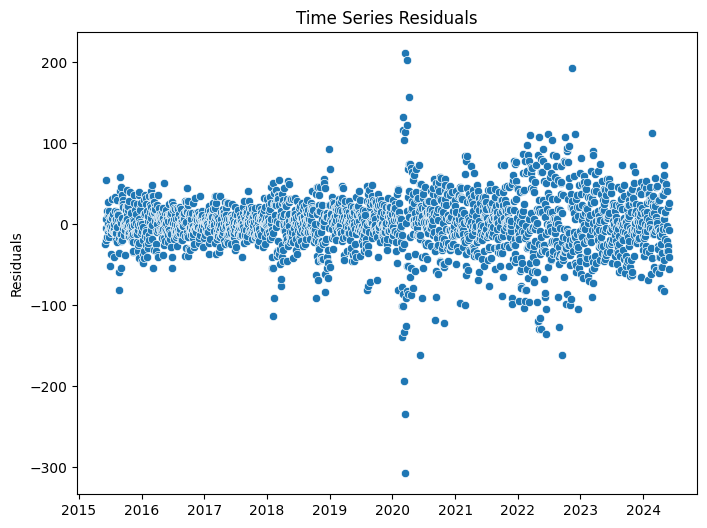

In [ ]:
# Residuals of the decomposed series - stationary data
plt.figure(figsize=(8,6))
sns.scatterplot(data=decomp_diff.resid)
plt.title('Time Series Residuals')
plt.ylabel('Residuals')
plt.savefig('Time Series Residuals - Stationary Data.png')
plt.show()

The residuals are centered at zero, which means that the mean is zero and the data is stationary.

In [ ]:
# Run auto_arima on original data set to check seasonality and get Python's recommended (p, d, q) values
stepwise_fit = auto_arima(ts, trace=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=25241.223, Time=1.53 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=25323.132, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=25308.355, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=25309.679, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=25325.708, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=25307.769, Time=0.62 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=25308.022, Time=0.26 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=25242.422, Time=1.53 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=25308.156, Time=1.64 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=25307.093, Time=0.32 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=25307.103, Time=1.08 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=25307.754, Time=0.82 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=25243.783, Time=2.03 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=25244.358, Time=0.62 sec

Best model:  ARIMA

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2517
Model:               SARIMAX(2, 1, 2)   Log Likelihood              -12614.611
Date:                Thu, 09 Jan 2025   AIC                          25241.223
Time:                        16:36:34   BIC                          25276.205
Sample:                             0   HQIC                         25253.919
                               - 2517                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.7577      2.626      2.193      0.028       0.611      10.905
ar.L1         -1.7636      0.021    -85.563      0.000      -1.804      -1.723
ar.L2         -0.8819      0.020    -45.098      0.000      -0.920      -0.844
ma.L1          1.6990      0.025     66.915      0.000       1.649       1.749
ma.L2          0.7996      0.024     32.930      0.000       0.752       0.847
sigma2      1325.5007     21.108     62.795      0.000    1284.129    1366.872
===================================================================================
Ljung-Box (L1) (Q):                   0.40   Jarque-Bera (JB):              3528.26
Prob(Q):                              0.53   Prob(JB):                         0.00
Heteroskedasticity (H):               6.55   Skew:                            -0.64
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<b> Best model:  ARIMA(2,1,2)(0,0,0)[0] <br>
AIC=25241.223

In [ ]:
# Run auto_arima on training data
stepwise_fit_train = auto_arima(train, trace=True)
stepwise_fit_train.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=20088.431, Time=0.98 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=20192.687, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=20168.336, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=20171.188, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=20192.046, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=20165.587, Time=0.20 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=20166.089, Time=0.20 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=20089.872, Time=1.12 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=20167.202, Time=1.17 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=20165.978, Time=0.18 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=20165.559, Time=0.77 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=20166.840, Time=0.81 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=20091.694, Time=1.63 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=20088.024, Time=0.38 sec
 ARIMA(1,1,2)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2013
Model:               SARIMAX(2, 1, 2)   Log Likelihood              -10039.012
Date:                Thu, 09 Jan 2025   AIC                          20088.024
Time:                        16:36:44   BIC                          20116.059
Sample:                             0   HQIC                         20098.315
                               - 2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7581      0.018    -99.000      0.000      -1.793      -1.723
ar.L2         -0.8856      0.017    -53.287      0.000      -0.918      -0.853
ma.L1          1.6766      0.023     73.127      0.000       1.632       1.721
ma.L2          0.7824      0.022     36.120      0.000       0.740       0.825
sigma2      1262.4715     20.079     62.876      0.000    1223.118    1301.825
===================================================================================
Ljung-Box (L1) (Q):                   0.26   Jarque-Bera (JB):              4260.28
Prob(Q):                              0.61   Prob(JB):                         0.00
Heteroskedasticity (H):               7.96   Skew:                            -0.78
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<b> Best model:  ARIMA(2,1,2)(0,0,0)[0] <br>
AIC=20088.024

### D. ANALYSIS

In [ ]:
# Identify an ARIMA model
# From auto_arima -> Best model:  ARIMA(2,1,2)(0,0,0)[0] 
model = ARIMA(ts.reset_index(drop=True), order=(2,1,2))
model = model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2517
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -12617.179
Date:                Thu, 09 Jan 2025   AIC                          25244.358
Time:                        16:36:45   BIC                          25273.510
Sample:                             0   HQIC                         25254.939
                               - 2517                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7642      0.021    -85.718      0.000      -1.805      -1.724
ar.L2         -0.8824      0.020    -45.191      0.000      -0.921      -0.844
ma.L1          1.7002      0.025     67.033      0.000       1.650       1.750
ma.L2          0.8007      0.024     33.002      0.000       0.753       0.848
sigma2      1328.1866     20.742     64.033      0.000    1287.533    1368.841
===================================================================================
Ljung-Box (L1) (Q):                   0.36   Jarque-Bera (JB):              3534.45
Prob(Q):                              0.55   Prob(JB):                         0.00
Heteroskedasticity (H):               6.57   Skew:                            -0.64
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# ARIMA model
model2 = ARIMA(ts.reset_index(drop=True), order=(2,1,1))
model2 = model2.fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2517
Model:                 ARIMA(2, 1, 1)   Log Likelihood              -12651.491
Date:                Thu, 09 Jan 2025   AIC                          25310.983
Time:                        16:36:45   BIC                          25334.304
Sample:                             0   HQIC                         25319.447
                               - 2517                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1533      0.244     -0.628      0.530      -0.632       0.325
ar.L2          0.0371      0.024      1.569      0.117      -0.009       0.084
ma.L1          0.0773      0.243      0.318      0.750      -0.399       0.553
sigma2      1366.0745     19.776     69.076      0.000    1327.313    1404.836
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              5060.81
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               6.60   Skew:                            -0.61
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# ARIMA model
model3 = ARIMA(ts.reset_index(drop=True), order=(1,1,2))
model3 = model3.fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2517
Model:                 ARIMA(1, 1, 2)   Log Likelihood              -12651.358
Date:                Thu, 09 Jan 2025   AIC                          25310.716
Time:                        16:36:45   BIC                          25334.038
Sample:                             0   HQIC                         25319.181
                               - 2517                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1977      0.199     -0.994      0.320      -0.587       0.192
ma.L1          0.1222      0.197      0.620      0.535      -0.264       0.508
ma.L2          0.0367      0.020      1.805      0.071      -0.003       0.077
sigma2      1367.2096     19.778     69.129      0.000    1328.446    1405.973
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              5032.79
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               6.60   Skew:                            -0.61
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# From auto_arima -> Best model:  ARIMA(2,1,2)(0,0,0)[0] 
modelT = ARIMA(train.reset_index(drop=True), order=(2,1,2))
modelT = modelT.fit()
modelT.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2013
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -10039.012
Date:                Thu, 09 Jan 2025   AIC                          20088.024
Time:                        16:36:46   BIC                          20116.059
Sample:                             0   HQIC                         20098.315
                               - 2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7581      0.018    -99.000      0.000      -1.793      -1.723
ar.L2         -0.8856      0.017    -53.287      0.000      -0.918      -0.853
ma.L1          1.6766      0.023     73.127      0.000       1.632       1.721
ma.L2          0.7824      0.022     36.120      0.000       0.740       0.825
sigma2      1262.4715     20.079     62.876      0.000    1223.118    1301.825
===================================================================================
Ljung-Box (L1) (Q):                   0.26   Jarque-Bera (JB):              4260.28
Prob(Q):                              0.61   Prob(JB):                         0.00
Heteroskedasticity (H):               7.96   Skew:                            -0.78
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# ARIMA model
modelT2 = ARIMA(train.reset_index(drop=True), order=(2,1,1))
modelT2 = modelT2.fit()
modelT2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2013
Model:                 ARIMA(2, 1, 1)   Log Likelihood              -10078.812
Date:                Thu, 09 Jan 2025   AIC                          20165.623
Time:                        16:36:46   BIC                          20188.051
Sample:                             0   HQIC                         20173.856
                               - 2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1161      0.196     -0.592      0.554      -0.500       0.268
ar.L2          0.0555      0.025      2.192      0.028       0.006       0.105
ma.L1          0.0091      0.195      0.047      0.963      -0.373       0.392
sigma2      1316.4524     19.570     67.268      0.000    1278.095    1354.810
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              6204.06
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               8.19   Skew:                            -0.73
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# ARIMA model
modelT3 = ARIMA(train.reset_index(drop=True), order=(1,1,2))
modelT3 = modelT3.fit()
modelT3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2013
Model:                 ARIMA(1, 1, 2)   Log Likelihood              -10078.548
Date:                Thu, 09 Jan 2025   AIC                          20165.096
Time:                        16:36:46   BIC                          20187.523
Sample:                             0   HQIC                         20173.328
                               - 2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1733      0.151     -1.146      0.252      -0.470       0.123
ma.L1          0.0669      0.150      0.447      0.655      -0.226       0.360
ma.L2          0.0542      0.021      2.607      0.009       0.013       0.095
sigma2      1316.9938     19.526     67.449      0.000    1278.724    1355.264
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              6141.23
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               8.19   Skew:                            -0.73
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Comparing and Selecting the ARIMA Model with the best AIC
Original Dataset
1. Auto ARIMA on original dataset: Best Model Order 2,1,2; AIC = 25241.223
2. Manual ARIMA on model: Model Order 2,1,2; AIC = 25244.358
3. Manual ARIMA on model2: Model Order 2,1,1; AIC = 25310.983
4. Manual ARIMA on model3: Model Order 1,1,2; AIC = 25310.716

Training Dataset
1. Auto ARIMA on training dataset: Best Model Order 2,1,2; AIC = 20088.024
2. Manual ARIMA on modelT: <b>Model Order 2,1,2; AIC = 20088.024<b>
3. Manual ARIMA on modelT2: Model Order 2,1,1; AIC = 20165.623
4. Manual ARIMA on modelT3: Model Order 1,1,2; AIC = 20165.096

#### Forecasting using ARIMA Model

In [ ]:
ts.head

<bound method NDFrame.head of 2014-12-01 21:00:00+00:00    2053.44
2014-12-02 21:00:00+00:00    2066.55
2014-12-03 21:00:00+00:00    2074.33
2014-12-04 21:00:00+00:00    2071.92
2014-12-05 21:00:00+00:00    2075.37
                              ...   
2024-11-22 21:00:00+00:00    5969.34
2024-11-25 21:00:00+00:00    5987.37
2024-11-26 21:00:00+00:00    6021.63
2024-11-27 21:00:00+00:00    5998.74
2024-11-29 18:00:00+00:00    6032.38
Length: 2517, dtype: float64>

In [ ]:
# Forecast the same length as the test set
pred = modelT.get_prediction(start=len(train)+1, end=len(ts))

In [ ]:
pm = pred.predicted_mean
pm.index = pd.to_datetime(test.index)
print(pm)

2022-11-29 21:00:00+00:00    3964.904352
2022-11-30 21:00:00+00:00    3966.132380
2022-12-01 21:00:00+00:00    3966.086735
2022-12-02 21:00:00+00:00    3965.079416
2022-12-05 21:00:00+00:00    3966.890834
                                ...     
2024-11-22 21:00:00+00:00    3965.821378
2024-11-25 21:00:00+00:00    3965.821378
2024-11-26 21:00:00+00:00    3965.821378
2024-11-27 21:00:00+00:00    3965.821378
2024-11-29 18:00:00+00:00    3965.821378
Name: predicted_mean, Length: 504, dtype: float64


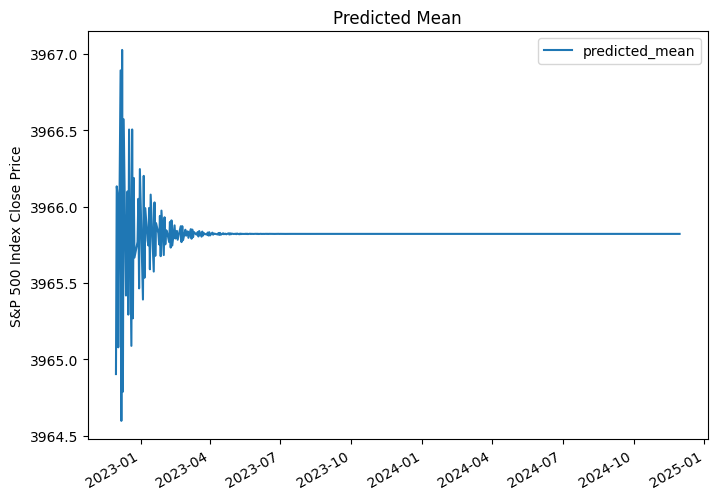

In [ ]:
plt.figure(figsize=(8,6))
plt.title('Predicted Mean')
plt.ylabel('S&P 500 Index Close Price')
pm.plot(legend=True)
plt.savefig('Predicted Mean.png')

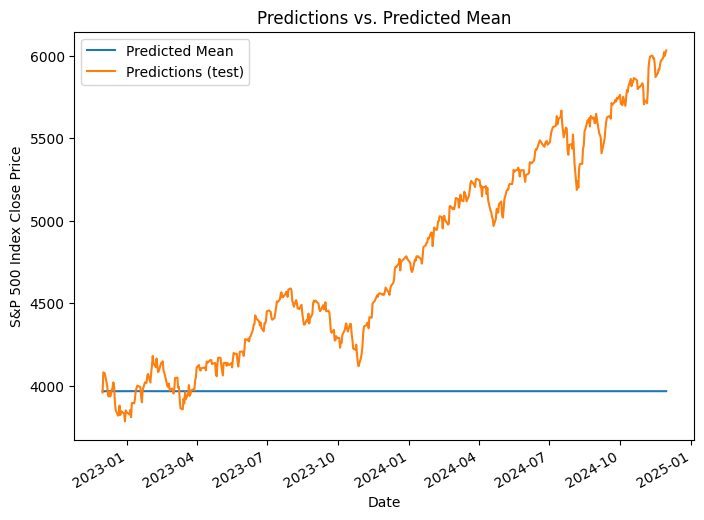

In [ ]:
plt.figure(figsize=(8,6))
pm.plot(legend=True, label='Predicted Mean')
test.plot(legend=True, label='Predictions (test)')
plt.title('Predictions vs. Predicted Mean')
plt.xlabel('Date')
plt.ylabel('S&P 500 Index Close Price')
plt.savefig('Predictions vs. Predicted Mean.png')

In [ ]:
# Obtain confidence intervals
conf_int = pred.conf_int(alpha=0.1)

# Lower and Upper Limits
lower_lim = conf_int.loc[:,'lower y']
upper_lim = conf_int.loc[:,'upper y']

lower_lim.index = pd.to_datetime(test.index)
upper_lim.index = pd.to_datetime(test.index)

print(lower_lim)
print(upper_lim)

2022-11-29 21:00:00+00:00    3885.551529
2022-11-30 21:00:00+00:00    3868.993390
2022-12-01 21:00:00+00:00    3853.903814
2022-12-02 21:00:00+00:00    3840.628937
2022-12-05 21:00:00+00:00    3829.700610
                                ...     
2024-11-22 21:00:00+00:00    2723.896434
2024-11-25 21:00:00+00:00    2722.657806
2024-11-26 21:00:00+00:00    2721.420410
2024-11-27 21:00:00+00:00    2720.184245
2024-11-29 18:00:00+00:00    2718.949304
Name: lower y, Length: 504, dtype: float64
2022-11-29 21:00:00+00:00    4044.257175
2022-11-30 21:00:00+00:00    4063.271369
2022-12-01 21:00:00+00:00    4078.269656
2022-12-02 21:00:00+00:00    4089.529895
2022-12-05 21:00:00+00:00    4104.081059
                                ...     
2024-11-22 21:00:00+00:00    5207.746322
2024-11-25 21:00:00+00:00    5208.984950
2024-11-26 21:00:00+00:00    5210.222345
2024-11-27 21:00:00+00:00    5211.458511
2024-11-29 18:00:00+00:00    5212.693451
Name: upper y, Length: 504, dtype: float64


### Output and Calculations

In [ ]:
# Check if test points fall within the bounds
within_ci = (test >= lower_lim) & (test <= upper_lim)

# Percentage of test points within the bounds
percentage_within_ci = np.sum(within_ci) / len(test) * 100

print(within_ci)

print("Percentage of test points within the confidence intervals: ", round(percentage_within_ci,2),"%")

2022-11-29 21:00:00+00:00     True
2022-11-30 21:00:00+00:00    False
2022-12-01 21:00:00+00:00     True
2022-12-02 21:00:00+00:00     True
2022-12-05 21:00:00+00:00     True
                             ...  
2024-11-22 21:00:00+00:00    False
2024-11-25 21:00:00+00:00    False
2024-11-26 21:00:00+00:00    False
2024-11-27 21:00:00+00:00    False
2024-11-29 18:00:00+00:00    False
Length: 504, dtype: bool
Percentage of test points within the confidence intervals:  58.13 %


In [ ]:
# Root mean squared error metric - test data
rmse = np.sqrt(mse(pred.predicted_mean, test))
print('RMSE of Test Data:', round(rmse, 2))

RMSE of Test Data: 1019.36


#### Annotated Visualization

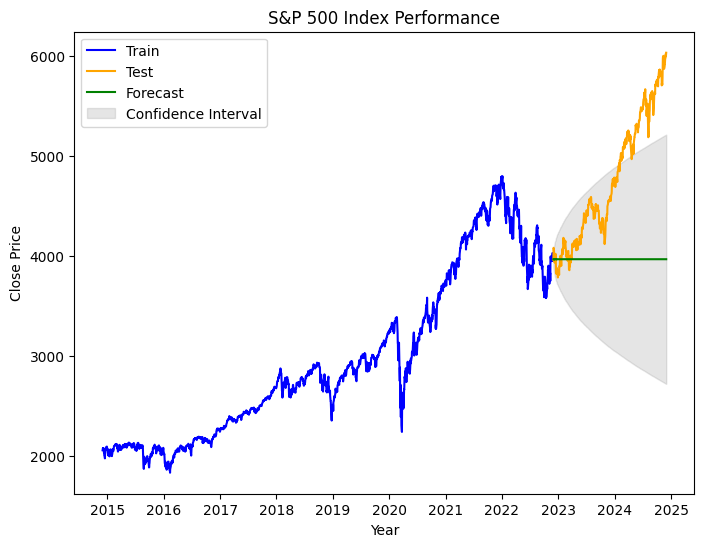

In [ ]:
# S&P 500 Index Performance 
plt.figure(figsize=(8,6))
plt.plot(train, label="Train", color='b')
plt.plot(test, label="Test", color='orange')
plt.plot(pm, label="Forecast", color='g')
plt.fill_between(lower_lim.index, lower_lim, upper_lim, color='grey', alpha=0.2, label='Confidence Interval')
plt.title('S&P 500 Index Performance')
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.legend()
plt.savefig('S&P 500 Index Analysis.png')